In [1]:
pip install pandas numpy matplotlib ripser persim tqdm joblib statsmodels scikit-learn

  Using cached ripser-0.6.14-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cached persim-0.3.8-py3-none-any.whl.metadata (3.8 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached hopcroftkarp-1.2.5-py2.py3-none-any.whl
Using cached ripser-0.6.14-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (839 kB)
Using cached persim-0.3.8-py3-none-any.whl (48 kB)
Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ripser]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

unemp = pd.read_csv("unemp_rate_state.csv")
hpa = pd.read_stata("hpa.dta")
ipums = pd.read_stata("ipums_processed.dta")

print(unemp.head())
print(hpa.head())
print(ipums.head())




import pandas as pd

pop = pd.read_stata("pop.dta")
print(pop.columns.tolist())
print(pop.head())

     state  year month  unemp_rate  labor_force      emp   unemp  naics1  \
0  ALABAMA  1976   jan         7.9      1479554  1362852  116702    12.1   
1  ALABAMA  1976   feb         7.7      1483434  1368596  114838    12.1   
2  ALABAMA  1976   mar         6.1      1473416  1383132   90284    12.1   
3  ALABAMA  1976   apr         5.7      1478039  1394337   83702    12.1   
4  ALABAMA  1976   may         5.2      1471784  1395094   76690    12.1   

   p_naics1     naics2  ...     naics5  p_naics5      naics6  p_naics6  \
0  0.007765  81.099998  ...  23.200001  0.014888  211.899994  0.135982   
1  0.007765  81.099998  ...  23.200001  0.014888  211.899994  0.135982   
2  0.007765  81.099998  ...  23.200001  0.014888  211.899994  0.135982   
3  0.007765  81.099998  ...  23.200001  0.014888  211.899994  0.135982   
4  0.007765  81.099998  ...  23.200001  0.014888  211.899994  0.135982   

   naics7  p_naics7     naics8  p_naics8      naics9  p_naics9  
0   166.5  0.106847  79.199997  0


Published weights (author weights):
KENTUCKY        0.421578
CONNECTICUT     0.215784
DELAWARE        0.130869
NORTH DAKOTA    0.106893
ARIZONA         0.104895
MINNESOTA       0.011988
OKLAHOMA        0.007992
dtype: float64
Saved figure: outputs_authorweight/author_replication_figure13.pdf


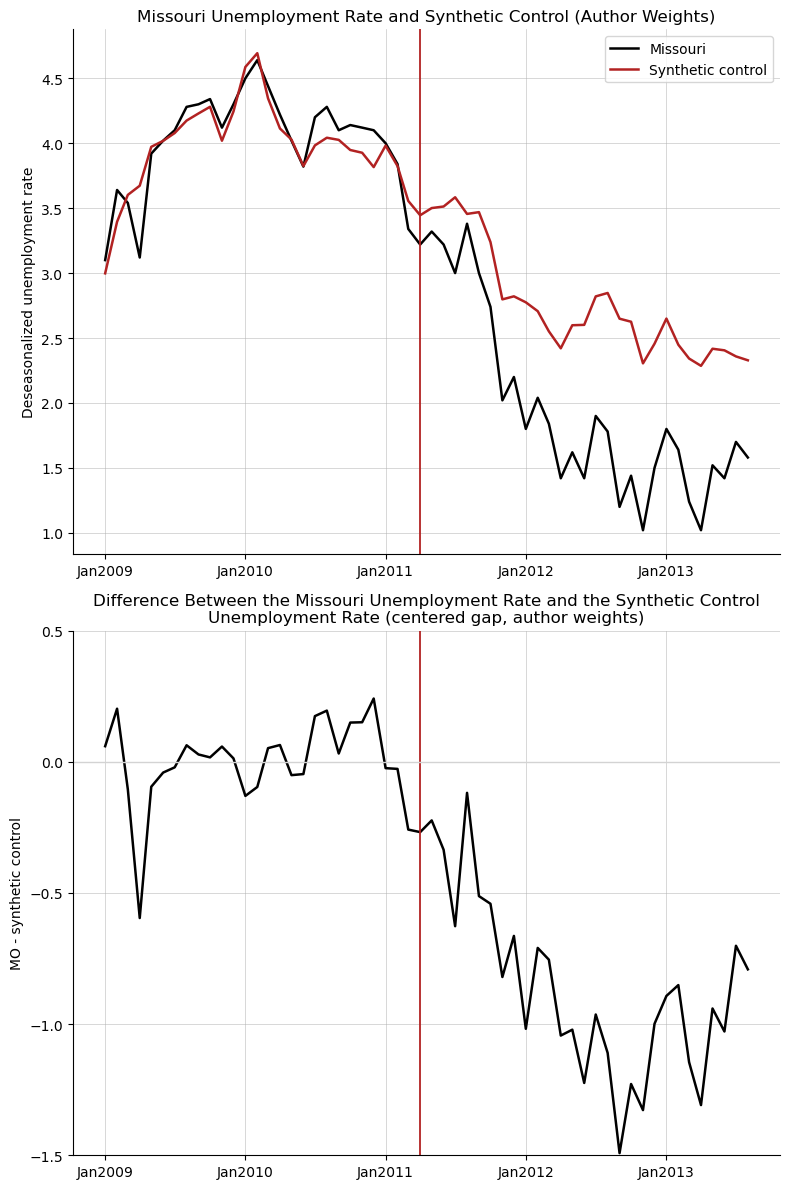


Diagnostics (author weights)
treated_state  trperiod treatment_date  pre_rmspe_author  post_rmspe_author  post_pre_ratio_author  n_donors  n_periods_total  n_periods_pre  n_periods_post
     MISSOURI       424     2011-04-01          0.161946           0.915605               5.653763        45               56             27              29

Saved outputs in: outputs_authorweight
 - author_weights.csv
 - authorweight_df.csv
 - author_replication_figure13.pdf
 - authorweight_diagnostics.csv
 - time_lookup.csv
 - panel_df_processed.csv


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# 0) Output folder
# ============================================================
OUTPUT_DIR = "outputs_authorweight"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")

# ============================================================
# 1) Read files
# ============================================================
unemp = pd.read_csv("unemp_rate_state.csv")
hpa = pd.read_stata("hpa.dta")
pop = pd.read_stata("pop.dta")

# ============================================================
# 2) Helpers
# ============================================================
def clean_state(s):
    return s.astype(str).str.strip().str.upper()

month_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

def solve_w_given_v(X1, X0, v):
    """
    Given predictor weights v, solve donor weights w:
        min_w (X1 - X0 w)' V (X1 - X0 w)
        s.t. w >= 0, sum(w) = 1
    """
    k, J = X0.shape
    V = np.diag(v)

    def obj(w):
        d = X1 - X0 @ w
        return float(d.T @ V @ d)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J
    w0 = np.repeat(1.0 / J, J)

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"W optimization failed: {res.message}")
    return res.x

def fit_synth_nested(X1, X0, Z1, Z0):
    """
    Standard nested synthetic-control logic:
      - inner loop: choose w given predictor-weight vector v
      - outer loop: choose v to minimize pre-treatment MSPE in Z
    """
    k = X0.shape[0]

    def outer_obj(v_raw):
        v = np.maximum(v_raw, 1e-10)
        v = v / v.sum()
        w = solve_w_given_v(X1, X0, v)
        z_gap = Z1 - Z0 @ w
        return float(np.mean(z_gap ** 2))

    v0 = np.repeat(1.0 / k, k)
    cons = [{"type": "eq", "fun": lambda v: np.sum(v) - 1.0}]
    bounds = [(1e-10, 1.0)] * k

    res_v = minimize(outer_obj, v0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res_v.success:
        raise RuntimeError(f"V optimization failed: {res_v.message}")

    v_star = np.maximum(res_v.x, 1e-10)
    v_star = v_star / v_star.sum()
    w_star = solve_w_given_v(X1, X0, v_star)

    return v_star, w_star

# ============================================================
# 3) Clean and construct time index
# ============================================================
unemp["state"] = clean_state(unemp["state"])
hpa["state"] = clean_state(hpa["state"])
pop["state"] = clean_state(pop["state"])

unemp["month_num"] = unemp["month"].str.lower().map(month_map)
unemp["date"] = pd.to_datetime(dict(year=unemp["year"], month=unemp["month_num"], day=1))

time_lookup = (
    unemp[["year", "month_num", "date"]]
    .drop_duplicates()
    .sort_values(["year", "month_num"])
    .reset_index(drop=True)
)
time_lookup["mo_yr"] = np.arange(1, len(time_lookup) + 1)

unemp = unemp.merge(
    time_lookup[["year", "month_num", "mo_yr"]],
    on=["year", "month_num"],
    how="left"
)

# Keep broad sample window as in Stata script
unemp = unemp[(unemp["year"] > 2000) & (unemp["year"] < 2015)].copy()

# Save time lookup
time_lookup.to_csv(os.path.join(OUTPUT_DIR, "time_lookup.csv"), index=False)

# ============================================================
# 4) Build variables used by Figure 13 synth block
# ============================================================
unemp["p12"] = unemp["p_naics1"] + unemp["p_naics2"]
unemp.loc[unemp["p_naics2"].isna(), "p12"] = unemp.loc[unemp["p_naics2"].isna(), "p_naics1"]

hpa_small = hpa[["state", "year", "index_sa"]].copy()

price_1999 = hpa_small.loc[hpa_small["year"] == 1999, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE1999"})
price_2006 = hpa_small.loc[hpa_small["year"] == 2006, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2006"})
price_2007 = hpa_small.loc[hpa_small["year"] == 2007, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2007"})
price_2010 = hpa_small.loc[hpa_small["year"] == 2010, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2010"})

hpi = (
    price_1999
    .merge(price_2006, on="state", how="inner")
    .merge(price_2007, on="state", how="inner")
    .merge(price_2010, on="state", how="inner")
)

hpi["Chg1999_2006"] = hpi["PRICE2006"] - hpi["PRICE1999"]
hpi["Chg2007_2010"] = hpi["PRICE2010"] - hpi["PRICE2007"]
hpi = hpi[["state", "Chg1999_2006", "Chg2007_2010"]]

pop_small = pop[["state", "pct_rural"]].drop_duplicates()

df = (
    unemp
    .merge(hpi, on="state", how="left")
    .merge(pop_small, on="state", how="left")
    .sort_values(["state", "year", "month_num"])
    .reset_index(drop=True)
)

# Save processed panel
df.to_csv(os.path.join(OUTPUT_DIR, "panel_df_processed.csv"), index=False)

# ============================================================
# 5) Deseasonalize
# ============================================================
train_means = (
    df.loc[df["year"] < 2006]
    .groupby(["state", "month_num"], as_index=False)["unemp_rate"]
    .mean()
    .rename(columns={"unemp_rate": "seasonal_mean"})
)

df = df.merge(train_means, on=["state", "month_num"], how="left")
df["unemp_rate_ds"] = df["unemp_rate"] - df["seasonal_mean"]
df["unemp_s"] = df["unemp_rate_ds"]

# ============================================================
# 6) Reproduce Figure 13 sample
# ============================================================
drop_states = {"FLORIDA", "ARKANSAS", "MICHIGAN", "SOUTH CAROLINA", "GEORGIA"}
synth_df = df.loc[~df["state"].isin(drop_states)].copy()
synth_df = synth_df[(synth_df["mo_yr"] >= 397) & (synth_df["mo_yr"] <= 452)].copy()

treated_state = "MISSOURI"
trperiod = 424

# ============================================================
# 7) Build predictor matrix
# ============================================================
anchor_static = 409
anchor_unemp = [397, 401, 405, 409, 413, 417, 421, 425]

all_states = sorted(synth_df["state"].unique().tolist())
donor_states = [s for s in all_states if s != treated_state]

static_cols = ["pct_rural", "Chg1999_2006", "Chg2007_2010", "p12", "p_naics3", "p_naics4"]

static_block = (
    synth_df.loc[synth_df["mo_yr"] == anchor_static, ["state"] + static_cols]
    .drop_duplicates(subset=["state"])
    .set_index("state")
)

dyn_block = (
    synth_df.loc[synth_df["mo_yr"].isin(anchor_unemp), ["state", "mo_yr", "unemp_s"]]
    .pivot(index="state", columns="mo_yr", values="unemp_s")
)
dyn_block.columns = [f"unemp_s_{c}" for c in dyn_block.columns]

X = static_block.join(dyn_block, how="inner").sort_index()

X1 = X.loc[treated_state].values.astype(float)
X0 = X.loc[donor_states].T.values.astype(float)

# ============================================================
# 8) Build pre-treatment target
# ============================================================
pre_df = synth_df.loc[synth_df["mo_yr"] < trperiod, ["state", "mo_yr", "unemp_s"]].copy()
pre_wide = pre_df.pivot(index="mo_yr", columns="state", values="unemp_s").sort_index()

Z1 = pre_wide[treated_state].values.astype(float)
Z0 = pre_wide[donor_states].values.astype(float)

# ============================================================
# 9) Use published weights
# ============================================================
published_weights = {
    "KENTUCKY": 0.422,
    "CONNECTICUT": 0.216,
    "DELAWARE": 0.131,
    "NORTH DAKOTA": 0.107,
    "ARIZONA": 0.105,
    "MINNESOTA": 0.012,
    "OKLAHOMA": 0.008
}

missing = [st for st in published_weights if st not in donor_states]
if missing:
    print(f"Warning: Missing states in donor pool: {missing}")

author_weights = np.zeros(len(donor_states))
for i, st in enumerate(donor_states):
    author_weights[i] = published_weights.get(st, 0.0)

author_weights = author_weights / author_weights.sum()

author_weights_series = pd.Series(author_weights, index=donor_states).sort_values(ascending=False)
print("\nPublished weights (author weights):")
print(author_weights_series[author_weights_series > 0.001])

author_weights_series.to_csv(os.path.join(OUTPUT_DIR, "author_weights.csv"))

# ============================================================
# 10) Construct authorweight_df
# ============================================================
full_wide = (
    synth_df.loc[:, ["state", "mo_yr", "date", "unemp_s"]]
    .pivot_table(index=["mo_yr", "date"], columns="state", values="unemp_s")
    .sort_index()
)

authorweight_df = full_wide.reset_index().copy()
authorweight_df["synthetic_author"] = authorweight_df[donor_states].values @ author_weights
authorweight_df["treated"] = authorweight_df[treated_state]
authorweight_df["gap_raw_author"] = authorweight_df["treated"] - authorweight_df["synthetic_author"]

pre_mean_gap_author = authorweight_df.loc[
    authorweight_df["mo_yr"] < trperiod, "gap_raw_author"
].mean()

authorweight_df["gap_centered_author"] = (
    authorweight_df["gap_raw_author"] - pre_mean_gap_author
)

authorweight_df.to_csv(os.path.join(OUTPUT_DIR, "authorweight_df.csv"), index=False)

# ============================================================
# 11) Plot Figure 13 in paper style and auto-save PDF
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

xticks = pd.to_datetime([
    "2009-01-01",
    "2010-01-01",
    "2011-01-01",
    "2012-01-01",
    "2013-01-01"
])
xlabels = [d.strftime("Jan%Y") for d in xticks]

# top: levels
ax1.plot(authorweight_df["date"], authorweight_df["treated"],
         label="Missouri", color="black", linewidth=1.8)
ax1.plot(authorweight_df["date"], authorweight_df["synthetic_author"],
         label="Synthetic control", color="firebrick", linewidth=1.8)
ax1.axvline(pd.Timestamp("2011-04-01"), color="firebrick", linewidth=1.3)

ax1.set_title("Missouri Unemployment Rate and Synthetic Control (Author Weights)")
ax1.set_ylabel("Deseasonalized unemployment rate")
ax1.legend()
ax1.grid(True, linewidth=0.5, alpha=0.7)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels)

# bottom: centered gap
ax2.plot(authorweight_df["date"], authorweight_df["gap_centered_author"],
         color="black", linewidth=1.8)
ax2.axvline(pd.Timestamp("2011-04-01"), color="firebrick", linewidth=1.3)
ax2.axhline(0, color="lightgray", linewidth=1)

ax2.set_title(
    "Difference Between the Missouri Unemployment Rate and the Synthetic Control\n"
    "Unemployment Rate (centered gap, author weights)"
)
ax2.set_ylabel("MO - synthetic control")
ax2.set_ylim(-1.5, 0.5)
ax2.set_yticks(np.arange(-1.5, 0.51, 0.5))
ax2.grid(True, linewidth=0.5, alpha=0.7)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="x", labelbottom=True)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels)

plt.tight_layout()
save_fig(fig, "author_replication_figure13.pdf")
plt.show()

# ============================================================
# 12) Diagnostics and save
# ============================================================
pre_rmspe_author = np.sqrt(np.mean(
    authorweight_df.loc[authorweight_df["mo_yr"] < trperiod, "gap_centered_author"] ** 2
))
post_rmspe_author = np.sqrt(np.mean(
    authorweight_df.loc[authorweight_df["mo_yr"] >= trperiod, "gap_centered_author"] ** 2
))

diagnostics_author = pd.DataFrame([{
    "treated_state": treated_state,
    "trperiod": trperiod,
    "treatment_date": time_lookup.loc[time_lookup["mo_yr"] == trperiod, "date"].iloc[0],
    "pre_rmspe_author": pre_rmspe_author,
    "post_rmspe_author": post_rmspe_author,
    "post_pre_ratio_author": post_rmspe_author / pre_rmspe_author if pre_rmspe_author > 0 else np.nan,
    "n_donors": len(donor_states),
    "n_periods_total": len(authorweight_df),
    "n_periods_pre": int((authorweight_df["mo_yr"] < trperiod).sum()),
    "n_periods_post": int((authorweight_df["mo_yr"] >= trperiod).sum()),
}])

diagnostics_author.to_csv(os.path.join(OUTPUT_DIR, "authorweight_diagnostics.csv"), index=False)

print("\nDiagnostics (author weights)")
print(diagnostics_author.to_string(index=False))

print("\nSaved outputs in:", OUTPUT_DIR)
print(" - author_weights.csv")
print(" - authorweight_df.csv")
print(" - author_replication_figure13.pdf")
print(" - authorweight_diagnostics.csv")
print(" - time_lookup.csv")
print(" - panel_df_processed.csv")